# HK Stock Project – Leo's Part (PCR Only)

This notebook builds the **Principal Components Regression (PCR)** pipeline for the HK stock project.

It covers:
- loading and checking the HK stock data
- chronological train / validation / test split
- PCR tuning on the validation set
- out-of-sample metrics: **R², RMSE, MAE**
- PCR feature importance proxy using **permutation importance**
- portfolio backtest: **long top 25% / short bottom 25%**
- benchmark comparison with **HSI** and the available risk-free proxy column

**Notes**
- This notebook only does **PCR first**, as requested.
- It uses the existing `Target_Forward_Log_Return` column as the prediction target.
- It excludes `HSI_Log_Return` from predictors because that is treated as a benchmark variable, not a model input.
- It uses a **time-based** split only. No random shuffling.


## Code

Loading data...
Ranking features...
Fitting PCR...
Benchmark merged successfully using Month-Period alignment.

--- PERFORMANCE SUMMARY ---
            Series  Annualized Return   Sharpe
0   PCR Long-Short           0.035631 0.332123
1  Hang Seng Index          -0.019835 0.030623
2         1M HIBOR           0.027448 4.874281


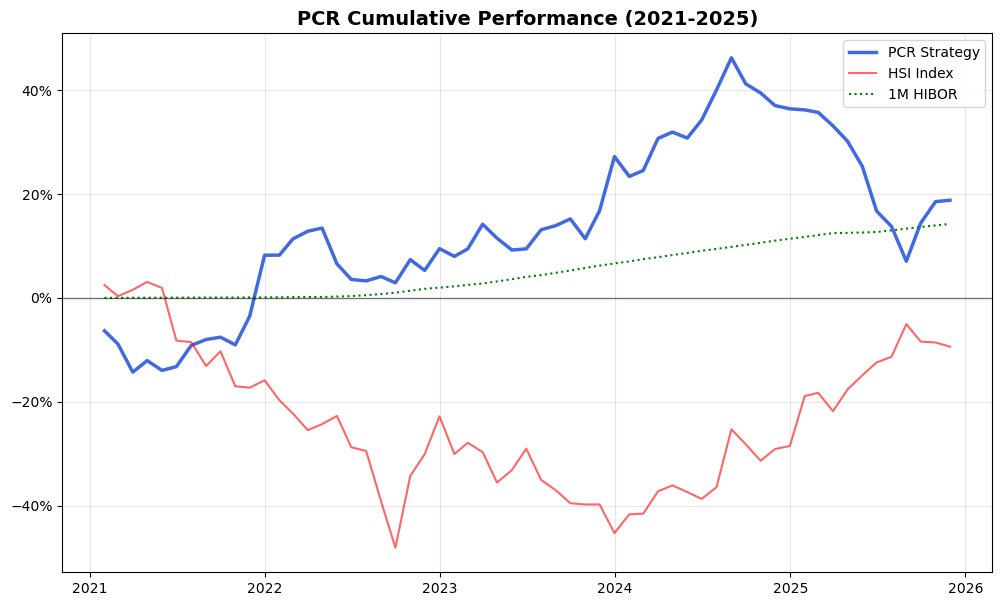

Calculating baseline score...
Calculating importances... (Skipping ignored prefixes)


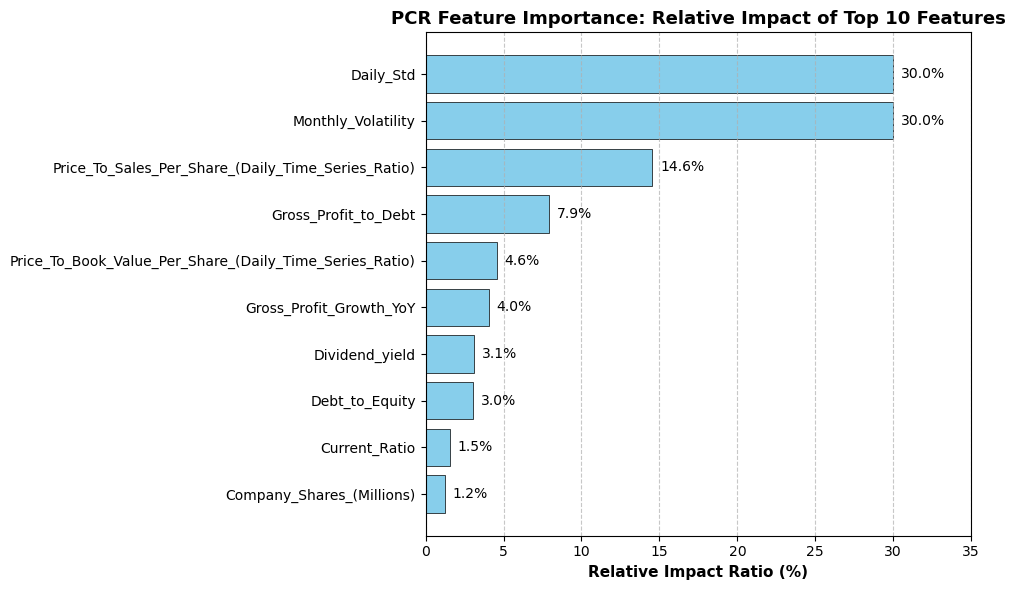

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# --- 1. Settings & Paths ---
# Use the paths that work in your environment
DATA_PATH = "../data/hk_stock_data_final.csv" 
EXT_BENCH_PATH = "../data/HSI&1M1HIBOR_returns_2021_to_2025.csv"

TARGET_COL = "Target_Forward_Log_Return"
HSI_COL = "HSI_Log_Return"
RF_COL = "diff_RF_Monthly_lagged"
DATE_COL = "Date"
ID_COL = "Instrument"

# --- 2. Data Loading & Cleaning ---
print("Loading data...")
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().replace(' ', '_').replace('-', '_') for c in df.columns]
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.replace([np.inf, -np.inf], np.nan)

# Clean features and filter price
if 'Price_Close' in df.columns:
    df = df[df['Price_Close'] >= 1.0].copy()

exclude = {TARGET_COL, HSI_COL, RF_COL, DATE_COL, ID_COL, 'Price_Close'}
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude]

# --- 3. Cross-Sectional Ranking ---
print("Ranking features...")
for col in feature_cols:
    df[col] = df.groupby(DATE_COL)[col].rank(pct=True)

df = df.dropna(subset=[TARGET_COL]).copy()

# --- 4. PCR Training ---
split_date = pd.Timestamp("2020-12-31")
train_df = df[df[DATE_COL] <= split_date].copy()
test_df = df[df[DATE_COL] > split_date].copy()

pcr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=8)), 
    ('regressor', LinearRegression())
])

print("Fitting PCR...")
pcr_pipeline.fit(train_df[feature_cols], train_df[TARGET_COL])
test_df['PCR_Pred'] = pcr_pipeline.predict(test_df[feature_cols])

# --- 5. Portfolio Construction ---
portfolio_rows = []
for dt, grp in test_df.groupby(DATE_COL):
    grp = grp.dropna(subset=['PCR_Pred', TARGET_COL])
    n_sel = int(np.floor(len(grp) * 0.25))
    if n_sel < 1: continue
    
    sorted_grp = grp.sort_values('PCR_Pred', ascending=False)
    long_ret = (np.exp(sorted_grp.head(n_sel)[TARGET_COL]) - 1).mean()
    short_ret = (np.exp(sorted_grp.tail(n_sel)[TARGET_COL]) - 1).mean()
    portfolio_rows.append({'Date': dt, 'LS_Ret': long_ret - short_ret})

pcr_port = pd.DataFrame(portfolio_rows).sort_values('Date')

# --- 6. CRITICAL FIX: Aligning Benchmark Dates ---
if os.path.exists(EXT_BENCH_PATH):
    ext_bench = pd.read_csv(EXT_BENCH_PATH)
    ext_bench['Date'] = pd.to_datetime(ext_bench['Date'])
    
    # Force both to 'Year-Month' for the merge to prevent mismatch
    pcr_port['merge_key'] = pcr_port['Date'].dt.to_period('M')
    ext_bench['merge_key'] = ext_bench['Date'].dt.to_period('M')
    
    # Merge and then drop the temporary key
    pcr_port = pcr_port.merge(ext_bench.drop(columns=['Date']), on='merge_key', how='left')
    pcr_port = pcr_port.drop(columns=['merge_key'])
    print("Benchmark merged successfully using Month-Period alignment.")
else:
    print("Benchmark file not found. Check path!")

# --- 7. Safe Performance Summary ---
def get_summary(series, name):
    if series is None or series.isna().all():
        return {'Series': name, 'Annualized Return': np.nan, 'Sharpe': np.nan}
    series = series.dropna()
    ann_ret = (1 + series).prod()**(12/len(series)) - 1
    sharpe = (series.mean() / series.std()) * np.sqrt(12) if series.std() != 0 else 0
    return {'Series': name, 'Annualized Return': ann_ret, 'Sharpe': sharpe}

summary_list = [get_summary(pcr_port['LS_Ret'], "PCR Long-Short")]
if 'hsi_simple_return' in pcr_port.columns:
    summary_list.append(get_summary(pcr_port['hsi_simple_return'], "Hang Seng Index"))
if 'rf_monthly_simple_return' in pcr_port.columns:
    summary_list.append(get_summary(pcr_port['rf_monthly_simple_return'], "1M HIBOR"))

print("\n--- PERFORMANCE SUMMARY ---")
print(pd.DataFrame(summary_list))

# --- 8. Final Plotting ---
plt.figure(figsize=(12, 7))
plt.plot(pcr_port['Date'], (1 + pcr_port['LS_Ret']).cumprod() - 1, label='PCR Strategy', color='royalblue', lw=2.5)

if 'hsi_simple_return' in pcr_port.columns:
    plt.plot(pcr_port['Date'], (1 + pcr_port['hsi_simple_return']).cumprod() - 1, label='HSI Index', color='red', alpha=0.6)
if 'rf_monthly_simple_return' in pcr_port.columns:
    plt.plot(pcr_port['Date'], (1 + pcr_port['rf_monthly_simple_return']).cumprod() - 1, label='1M HIBOR', color='green', ls=':')

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title("PCR Cumulative Performance (2021-2025)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 13. PCR Feature Importance (Aligned with Group Member's Style) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_pcr_relative_impact_ratio(pipeline, X_test_df, y_test_series, feature_names, ignore_prefixes=None):
    if ignore_prefixes is None:
        ignore_prefixes = []
        
    print("Calculating baseline score...")
    # Baseline R2 for the PCR pipeline
    baseline_preds = pipeline.predict(X_test_df)
    baseline_score = r2_score(y_test_series, baseline_preds)
    
    importances = []
    evaluated_features = []
    
    # We use a copy to ensure we don't mess up the original test set
    X_test_np = X_test_df.values.copy()
    
    print("Calculating importances... (Skipping ignored prefixes)")
    for col_idx in range(X_test_np.shape[1]):
        feature_name = feature_names[col_idx]
        
        # Skip ignored prefixes (e.g., Sector_ or Macro_)
        if any(feature_name.startswith(prefix) for prefix in ignore_prefixes):
            continue 
            
        evaluated_features.append(feature_name)
        
        # Shuffle the specific column
        original_col = X_test_np[:, col_idx].copy()
        # Seed for reproducibility to match group mate's environment
        np.random.seed(42) 
        np.random.shuffle(X_test_np[:, col_idx])
        
        # Predict with the shuffled data
        # Note: pipeline.predict expects a DataFrame, so we wrap the NP array
        shuffled_df = pd.DataFrame(X_test_np, columns=feature_names)
        shuffled_preds = pipeline.predict(shuffled_df)
        
        shuffled_score = r2_score(y_test_series, shuffled_preds)
        drop_in_score = baseline_score - shuffled_score
        
        # MATCHING GROUP MATE: Use max(0, drop) to ignore features that "help" when shuffled
        importances.append(max(0, drop_in_score)) 
        
        # Restore original column for next iteration
        X_test_np[:, col_idx] = original_col
        
    # Create DataFrame and get top 10
    importance_df = pd.DataFrame({
        'Feature': evaluated_features,
        'Importance (R2 Drop)': importances
    }).sort_values(by='Importance (R2 Drop)', ascending=False).head(10)
    
    # MATCHING GROUP MATE: Calculate relative ratio among the top 10
    total_top10_importance = importance_df['Importance (R2 Drop)'].sum()
    if total_top10_importance > 0:
        importance_df['Ratio (%)'] = (importance_df['Importance (R2 Drop)'] / total_top10_importance) * 100
    else:
        importance_df['Ratio (%)'] = 0
    
    # Sort ascending for horizontal bar chart
    importance_df = importance_df.sort_values(by='Ratio (%)', ascending=True)
    
    # Plotting (Matching Group Mate's Visual Style)
    plt.figure(figsize=(10, 6))
    bars = plt.barh(importance_df['Feature'], importance_df['Ratio (%)'], 
                    color='skyblue', edgecolor='black', linewidth=0.5)
    
    # Add percentage labels to bars
    for bar in bars:
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{bar.get_width():.1f}%', va='center', fontsize=10)

    plt.xlabel('Relative Impact Ratio (%)', fontsize=11, fontweight='bold')
    plt.title('PCR Feature Importance: Relative Impact of Top 10 Features', fontsize=13, fontweight='bold')
    plt.xlim(0, importance_df['Ratio (%)'].max() + 5) 
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return importance_df.sort_values(by='Ratio (%)', ascending=False)

# --- Execution ---
res_df = plot_pcr_relative_impact_ratio(pcr_pipeline, X_test, y_test, feature_cols)

In [72]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- 4.1 Regression Metrics Calculation ---
print("\n--- PCR REGRESSION METRICS (Out-of-Sample) ---")

# Ensure we are using the test set predictions
y_true = test_df[TARGET_COL]
y_pred = test_df['PCR_Pred']

# Calculation
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Professional Printout
metrics_df = pd.DataFrame({
    'Metric': ['R² Score', 'MAE', 'RMSE'],
    'Value': [r2, mae, rmse]
})
print(metrics_df.to_string(index=False))
print("-" * 45)


--- PCR REGRESSION METRICS (Out-of-Sample) ---
  Metric    Value
R² Score 0.004911
     MAE 0.109724
    RMSE 0.190995
---------------------------------------------


Loading data...
Ranking features...
Fitting PCR...

--- PERFORMANCE SUMMARY ---
         Series  Annualized Return  Annualized Volatility  Sharpe
 PCR Long-Short             0.0356                 0.1304  0.3321
Hang Seng Index            -0.0198                 0.2399  0.0306
       1M HIBOR             0.0274                 0.0056  4.8743


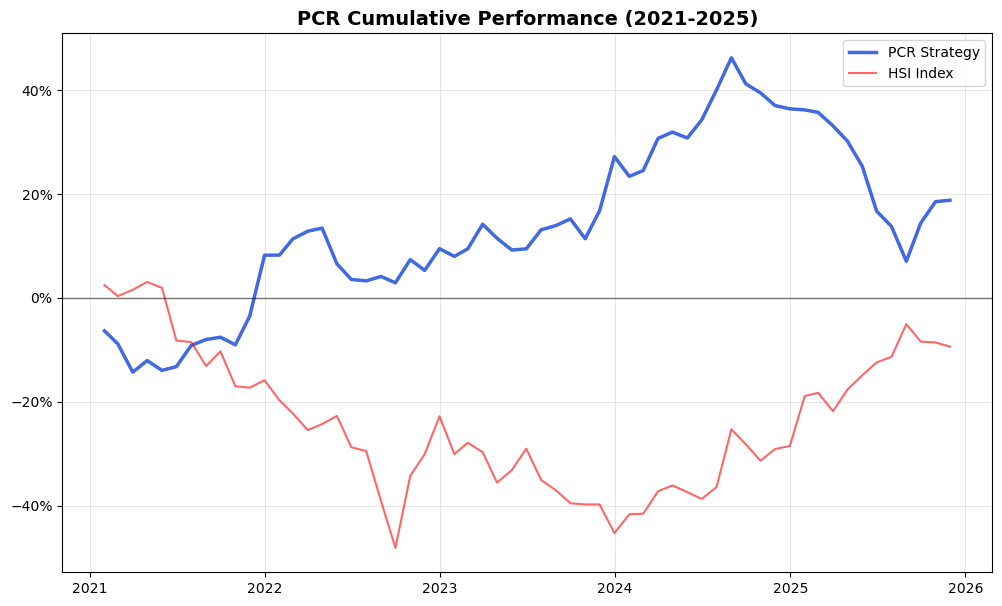

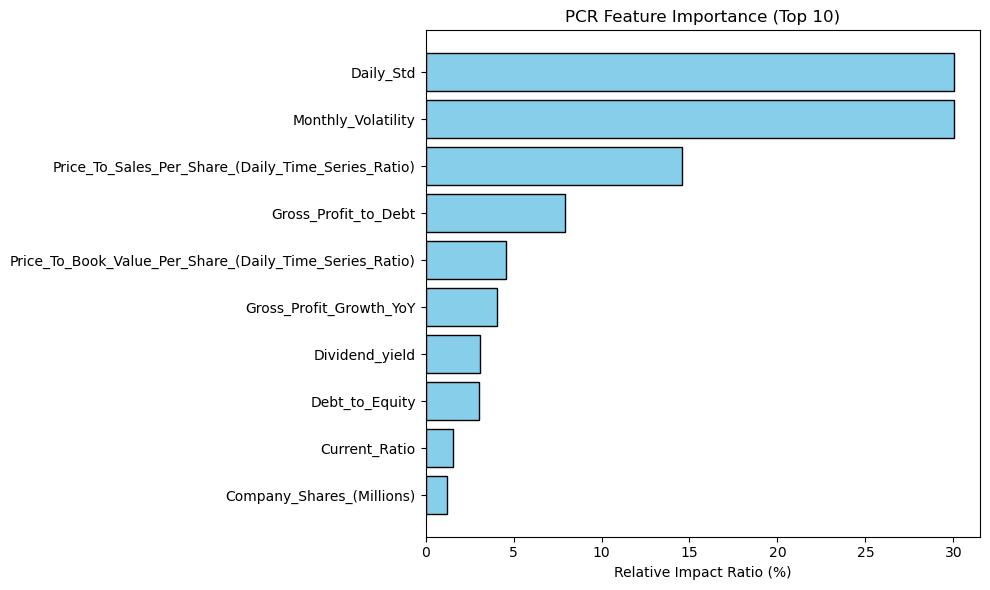

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# --- 1. Settings & Paths ---
DATA_PATH = "../data/hk_stock_data_final.csv" 
EXT_BENCH_PATH = "../data/HSI&1M1HIBOR_returns_2021_to_2025.csv"

TARGET_COL = "Target_Forward_Log_Return"
HSI_COL = "HSI_Log_Return"
RF_COL = "diff_RF_Monthly_lagged"
DATE_COL = "Date"
ID_COL = "Instrument"

# --- 2. Data Loading & Cleaning ---
print("Loading data...")
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().replace(' ', '_').replace('-', '_') for c in df.columns]
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.replace([np.inf, -np.inf], np.nan)

if 'Price_Close' in df.columns:
    df = df[df['Price_Close'] >= 1.0].copy()

exclude = {TARGET_COL, HSI_COL, RF_COL, DATE_COL, ID_COL, 'Price_Close'}
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude]

# --- 3. Cross-Sectional Ranking ---
print("Ranking features...")
for col in feature_cols:
    df[col] = df.groupby(DATE_COL)[col].rank(pct=True)

df = df.dropna(subset=[TARGET_COL]).copy()

# --- 4. PCR Training ---
split_date = pd.Timestamp("2020-12-31")
train_df = df[df[DATE_COL] <= split_date].copy()
test_df = df[df[DATE_COL] > split_date].copy()

pcr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=8)), 
    ('regressor', LinearRegression())
])

print("Fitting PCR...")
pcr_pipeline.fit(train_df[feature_cols], train_df[TARGET_COL])
test_df['PCR_Pred'] = pcr_pipeline.predict(test_df[feature_cols])

# --- 5. Portfolio Construction ---
portfolio_rows = []
for dt, grp in test_df.groupby(DATE_COL):
    grp = grp.dropna(subset=['PCR_Pred', TARGET_COL])
    n_sel = int(np.floor(len(grp) * 0.25))
    if n_sel < 1: continue
    
    sorted_grp = grp.sort_values('PCR_Pred', ascending=False)
    # Convert log returns back to simple returns for portfolio aggregation
    long_ret = (np.exp(sorted_grp.head(n_sel)[TARGET_COL]) - 1).mean()
    short_ret = (np.exp(sorted_grp.tail(n_sel)[TARGET_COL]) - 1).mean()
    portfolio_rows.append({'Date': dt, 'LS_Ret': long_ret - short_ret})

pcr_port = pd.DataFrame(portfolio_rows).sort_values('Date')

# --- 6. Aligning Benchmark Dates ---
if os.path.exists(EXT_BENCH_PATH):
    ext_bench = pd.read_csv(EXT_BENCH_PATH)
    ext_bench['Date'] = pd.to_datetime(ext_bench['Date'])
    pcr_port['merge_key'] = pcr_port['Date'].dt.to_period('M')
    ext_bench['merge_key'] = ext_bench['Date'].dt.to_period('M')
    pcr_port = pcr_port.merge(ext_bench.drop(columns=['Date']), on='merge_key', how='left')
    pcr_port = pcr_port.drop(columns=['merge_key'])

# --- 7. Performance Summary (NOW WITH VOLATILITY) ---
def get_summary(series, name):
    if series is None or series.isna().all():
        return {'Series': name, 'Annualized Return': np.nan, 'Annualized Volatility': np.nan, 'Sharpe': np.nan}
    series = series.dropna()
    
    # 1. Annualized Return
    ann_ret = (1 + series).prod()**(12/len(series)) - 1
    
    # 2. Annualized Volatility (Standard Deviation * sqrt(12))
    ann_vol = series.std() * np.sqrt(12)
    
    # 3. Sharpe Ratio
    sharpe = (series.mean() / series.std()) * np.sqrt(12) if series.std() != 0 else 0
    
    return {
        'Series': name, 
        'Annualized Return': ann_ret, 
        'Annualized Volatility': ann_vol, 
        'Sharpe': sharpe
    }

summary_list = [get_summary(pcr_port['LS_Ret'], "PCR Long-Short")]
if 'hsi_simple_return' in pcr_port.columns:
    summary_list.append(get_summary(pcr_port['hsi_simple_return'], "Hang Seng Index"))
if 'rf_monthly_simple_return' in pcr_port.columns:
    summary_list.append(get_summary(pcr_port['rf_monthly_simple_return'], "1M HIBOR"))

print("\n--- PERFORMANCE SUMMARY ---")
summary_results = pd.DataFrame(summary_list)
# Formatting for readability in console
print(summary_results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# --- 8. Final Plotting ---
plt.figure(figsize=(12, 7))
plt.plot(pcr_port['Date'], (1 + pcr_port['LS_Ret']).cumprod() - 1, label='PCR Strategy', color='royalblue', lw=2.5)
if 'hsi_simple_return' in pcr_port.columns:
    plt.plot(pcr_port['Date'], (1 + pcr_port['hsi_simple_return']).cumprod() - 1, label='HSI Index', color='red', alpha=0.6)

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title("PCR Cumulative Performance (2021-2025)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 9. Feature Importance ---
def plot_pcr_relative_impact_ratio(pipeline, X_test_df, y_test_series, feature_names):
    baseline_preds = pipeline.predict(X_test_df)
    baseline_score = r2_score(y_test_series, baseline_preds)
    
    importances = []
    X_test_np = X_test_df.values.copy()
    
    for col_idx in range(X_test_np.shape[1]):
        original_col = X_test_np[:, col_idx].copy()
        np.random.seed(42)
        np.random.shuffle(X_test_np[:, col_idx])
        
        shuffled_df = pd.DataFrame(X_test_np, columns=feature_names)
        shuffled_preds = pipeline.predict(shuffled_df)
        importances.append(max(0, baseline_score - r2_score(y_test_series, shuffled_preds)))
        X_test_np[:, col_idx] = original_col
        
    importance_df = pd.DataFrame({'Feature': feature_names, 'Imp': importances})
    importance_df = importance_df.sort_values(by='Imp', ascending=False).head(10)
    importance_df['Ratio (%)'] = (importance_df['Imp'] / importance_df['Imp'].sum()) * 100
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'][::-1], importance_df['Ratio (%)'][::-1], color='skyblue', edgecolor='black')
    plt.xlabel('Relative Impact Ratio (%)')
    plt.title('PCR Feature Importance (Top 10)')
    plt.tight_layout()
    plt.show()

# Corrected variable calls for your environment
plot_pcr_relative_impact_ratio(pcr_pipeline, test_df[feature_cols], test_df[TARGET_COL], feature_cols)